# TF binding dynamics in differentiation phases

Per-phase TF binding boxes for the PB and GC branches, built from the dictys chromatin
files (`binding.tsv.gz` per window) -- **no TF forces are used here**. Split out of
`Fig4_2_dynamic_validation.ipynb` (which validates links by TF force) because the
inputs (chromatin windows) and the outputs (binding trends per phase) are unrelated to
the force metric.

Per branch, two TF universes (X1/X2 for PB, Y1/Y2 for GC):

* **State-specific**: TFs of the state-specific links, assigned to the branch where their
  mean expression is higher (`tf_branch` column of `SS_LINKS_CSV`, written once by
  `assign_ss_tf_branch.py`).
* **Episodic**: the episodically enriched TFs of that branch (the Fig3_2 dotplot calls).

Within each branch a TF is ranked by the max of its smoothed binding curve over the
windows of each phase (post-bifurcation windows only); the top-5 per category are plotted.


In [1]:
# Dataset locations for this notebook come from ../datasets.yaml.
# Edit that file to point at your own copies -- do not hardcode paths below.
from focal.io import DatasetPaths

# DatasetPaths.find() walks up from the kernel's working directory to the first
# datasets.yaml (or uses $FOCAL_DATASETS), so it works wherever Jupyter was started.
config = DatasetPaths.find()


In [2]:
import numpy as np
import pandas as pd
import os
import ast

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

%matplotlib inline

plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": 'none'
})
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)

# All figures from this notebook are written as PDFs here (folder is gitignored).
RESULTS_DIR = os.path.join(os.getcwd(), 'Fig4_4_results')
os.makedirs(RESULTS_DIR, exist_ok=True)

def save_pdf(fig, name):
    fig.savefig(os.path.join(RESULTS_DIR, f"{name}.pdf"),
                format='pdf', bbox_inches='tight', transparent=True)

# Link-set palette, shared with Fig4_2 / state_specific/perturbation/PS_Bcell_dynamic.ipynb:
# state-specific = blue, episodic/dynamic = orange, random/other = light grey.
LINK_COLORS = {
    'State-specific': 'dodgerblue',
    'Episodic': 'tab:orange',
    'random': '#bbbbbb',
}
# BindingPhases.plot_box takes colormaps, not colours; single-colour maps give the same palette.
LINK_CMAPS = {k: mcolors.ListedColormap([v], name=f'link_{k}') for k, v in LINK_COLORS.items()}


In [3]:
import dictys

from focal.temporal import *      # classes AND their figures
from focal.utils import *         # gene / state helpers (was utils_custom)

In [4]:
import importlib
import focal.utils
import focal.temporal._source, focal.temporal._states, focal.temporal._chromatin
import focal.temporal._phases, focal.temporal.manager
# reload order matters: _phases imports from _states/_align; manager imports all of them.
for _m in (focal.utils, focal.temporal._source, focal.temporal._states,
           focal.temporal._chromatin, focal.temporal._phases,
           focal.temporal.manager, focal.temporal):
    importlib.reload(_m)
from focal.temporal import TrajectorySegments, StateFrequency, BindingPhases, SmoothedCurvesChromatin


In [5]:
# Load data
dictys_dynamic_object = dictys.net.dynamic_network.from_file(config.DYNAMIC_H5)

### Defining lineage trajectories

In [6]:
PB_fate_window_indices = [1] + list(range(97, 3, -1)) + [0] + list(range(98, 147, 1)) + [2]
GC_fate_window_indices = [1] + list(range(97, 3, -1)) + [0] + list(range(147, 193, 1)) + [3]
PB_post_bifurcation_window_indices = [0] + list(range(98, 147, 1)) + [2]
GC_post_bifurcation_window_indices = [0] + list(range(147, 193, 1)) + [3]

In [7]:
# Define distinct colors for better visibility
colors_cell_count = {
    'ActB-1': '#87CEFA',     # lightskyblue
    'ActB-2': '#1E90FF',     # dodgerblue
    'ActB-3': '#00008B',     # darkblue
    'ActB-4': '#9370DB',     # mediumorchid
    'GC-1': '#7BDE7B',       # custom light green
    'GC-2': '#008000',       # green
    'PB-2': '#BB3636',       # custom red
    'earlyActB': '#008080',   # teal
    'earlyPB': '#F08080'   # lightcoral
}

## TF universes

### State-specific link TFs (with their expression-assigned branch)

In [8]:
ss_focal_combined = pd.read_csv(config.SS_LINKS_CSV)

In [9]:
display(ss_focal_combined)

,source,target,key,weight,cluster,strength,case,confidence,tf_branch,tf_PB_mean_log2cpm,tf_GC_mean_log2cpm,tf_log2FC_PB_vs_GC
0,PRDM1,RUNX2,1.0,0.293075,3.0,1,slide,verified,PB,7.2741,5.0041,2.2699
1,PRDM1,IQGAP2,1.0,0.219831,3.0,1,slide,verified,PB,7.2741,5.0041,2.2699
2,BACH2,XBP1,0.0,-0.229950,7.0,1,slide,verified,GC,8.2889,9.5656,-1.2766
3,BACH2,MZB1,1.0,-0.234813,3.0,1,slide,verified,GC,8.2889,9.5656,-1.2766
4,BACH2,JCHAIN,1.0,-0.258168,3.0,1,slide,verified,GC,8.2889,9.5656,-1.2766
...,...,...,...,...,...,...,...,...,...,...,...,...
75,PBX3,CDK6,1.0,0.231756,3.0,1,slide,verified,GC,7.9557,8.9900,-1.0343
76,PBX3,AFF3,1.0,0.332018,3.0,1,slide,verified,GC,7.9557,8.9900,-1.0343
77,ARID5B,CPEB4,1.0,0.237878,3.0,1,slide,verified,PB,9.2263,9.0602,0.1661
78,ARID5B,PDE4D,0.0,0.228636,7.0,1,slide,verified,PB,9.2263,9.0602,0.1661


In [10]:
# Build (TF, target) tuples, keeping only links whose TF and target are both
# present in the dictys object. get_beta_curves can only compute forces for genes
# in the GRN (TFs in nids[0], targets in ndict); filtering here makes the computed
# link set explicit rather than relying on the internal skip.
all_links = list(zip(ss_focal_combined['source'], ss_focal_combined['target']))

_, _, missing_tfs = get_tf_indices(dictys_dynamic_object, list({tf for tf, _ in all_links}))
missing_tfs = set(missing_tfs)
ndict = dictys_dynamic_object.ndict

ss_focal_combined_tuple = [(tf, tg) for tf, tg in all_links
                     if tf not in missing_tfs and tg in ndict]
dropped = [(tf, tg) for tf, tg in all_links
           if tf in missing_tfs or tg not in ndict]
print(f"{len(ss_focal_combined_tuple)}/{len(all_links)} links kept; "
      f"{len(dropped)} dropped (TF/target absent from GRN): {dropped}")

68/80 links kept; 12 dropped (TF/target absent from GRN): [('AFF1', 'MAN1A1'), ('AFF1', 'FNDC3A'), ('AFF1', 'CEP128'), ('HERPUD1', 'TRAM1'), ('HERPUD1', 'IRF4'), ('HERPUD1', 'BTG2'), ('HERPUD1', 'PAX5'), ('HIVEP2', 'IRF4'), ('HIVEP2', 'BTG2'), ('HIVEP2', 'GAB1'), ('HIVEP2', 'GLCCI1'), ('HIVEP2', 'CPEB4')]


### Episodically enriched TFs per branch (Fig3_2 dotplot calls)

In [11]:
# Episodically enriched links, derived from the fixed per-branch enrichment tables
# (config.PB / config.GC, one CSV per episode; program = Z11 u Z3 GC-vs-PB latent factors,
# HLA- dropped, NOT Z11 alone -- see the note at the top of Fig3_2). Enriched TFs are the ones the Fig3_2
# dotplots call (>=2 LF targets, >=2 downstream genes, min p < 0.05); a link is
# (TF, LF target) from every episode where that TF passes p <= 0.05.
EPISODE_LABELS = ['Ep1', 'Ep2', 'Ep3', 'Ep4']
P_VALUE_THRESHOLD = 0.05

def parse_genes_in_lf(genes_str):
    try:
        if pd.isna(genes_str) or genes_str in ('', '()'):
            return ()
        val = ast.literal_eval(genes_str)
        return val if isinstance(val, tuple) else (val,)
    except Exception:
        return ()

def episodic_lf_links(group, lineage):
    dfs = [pd.read_csv(group[f'ep{i}']) for i in range(1, 5)]
    fig, _, enriched_tfs = plot_tf_episodic_enrichment_dotplot(
        dfs=dfs, episode_labels=EPISODE_LABELS,
        p_value_threshold=P_VALUE_THRESHOLD, min_significance_threshold=P_VALUE_THRESHOLD,
        show_plot=False,
    )
    plt.close(fig)
    rows = []
    for episode, df in zip(EPISODE_LABELS, dfs):
        sub = df[df['TF'].isin(enriched_tfs) & (df['p_value'] <= P_VALUE_THRESHOLD)]
        for _, r in sub.iterrows():
            for g in parse_genes_in_lf(r['genes_in_lf']):
                rows.append({'lineage': lineage, 'episode': episode, 'TF': r['TF'], 'target': g})
    return pd.DataFrame(rows), enriched_tfs

episodic_links_pb, enriched_tfs_pb = episodic_lf_links(config.PB, 'PB')
episodic_links_gc, enriched_tfs_gc = episodic_lf_links(config.GC, 'GC')
episodic_links = pd.concat([episodic_links_pb, episodic_links_gc], ignore_index=True)
print('PB enriched TFs:', enriched_tfs_pb)
print('GC enriched TFs:', enriched_tfs_gc)


Filtered to 35 TFs that meet gene count criteria
Further filtered to 10 TFs that meet significance threshold < 0.05
Filtered to 41 TFs that meet gene count criteria
Further filtered to 11 TFs that meet significance threshold < 0.05


PB enriched TFs: ['IKZF3', 'BHLHE40', 'TFEC', 'REL', 'MEF2C', 'MAX', 'STAT3', 'CREB3L2', 'MEF2A', 'RUNX3']
GC enriched TFs: ['CREB3L2', 'NFATC2', 'IRF1', 'IKZF3', 'RUNX3', 'CDC5L', 'MAX', 'MYC', 'MEF2C', 'STAT6', 'TCF12']


## Phase definitions

Segments are declared only to get each branch's cell-state composition along pseudotime; no forces are computed.

In [12]:
# One segment per branch (PB: node 0 -> 2, GC: node 0 -> 3). Only `state_frequency` is
# used from this object here (phase boundaries); the force machinery it also exposes is
# never touched, so this is cheap.
traj = TrajectorySegments(
    dictys_dynamic_object,
    {'PB': (0, 2), 'GC': (0, 3)},
    num_points=100,
    dist=0.0005,
    sparsity=0.01,
)


In [13]:
# Cell-state composition along each segment (the segment's range is filled in);
# termination pseudotimes are the phase boundaries.
sf_pb = traj.state_frequency('PB', config.CELL_LABELS, colors=colors_cell_count)
sf_gc = traj.state_frequency('GC', config.CELL_LABELS, colors=colors_cell_count)
pseudotime_values_of_windows_pb = sf_pb.pseudotime_values_of_windows
pseudotime_values_of_windows_gc = sf_gc.pseudotime_values_of_windows


In [14]:
# PB switch boundaries = termination pseudotimes of ActB-4 then earlyPB (3 phases).
pb_switches = [sf_pb.termination_pseudotime(s, PB_post_bifurcation_window_indices,
                                            method='threshold')
               for s in ['ActB-4', 'earlyPB']]

# GC switch boundary = termination pseudotime of ActB-3 (2 phases).
gc_switches = [sf_gc.termination_pseudotime('ActB-3', GC_post_bifurcation_window_indices,
                                            method='threshold')]

# TF Binding Dynamics

In [15]:
base_path = config.TMP_DYNAMIC
from focal.temporal import SmoothedCurvesChromatin

smooth_chromatin_object = SmoothedCurvesChromatin(
    tfs=None,
    base_path=base_path
)

In [16]:
aligner_pb = AlignTimeScales(dictys_dynamic_object, trajectory_range=(0, 2),
                             num_points=40, dist=0.001, sparsity=0.01)
aligner_gc = AlignTimeScales(dictys_dynamic_object, trajectory_range=(0, 3),
                             num_points=40, dist=0.001, sparsity=0.01)

window_pseudotimes_pb = aligner_pb.pseudotime_of_windows()
window_pseudotimes_gc = aligner_gc.pseudotime_of_windows()

smooth_chromatin_object.set_trajectory_info(
    pb_indices=[1] + list(range(97, 3, -1)) + [0] + list(range(98, 147, 1)) + [2],
    gc_indices=[1] + list(range(97, 3, -1)) + [0] + list(range(147, 193, 1)) + [3],
    window_pseudotimes=window_pseudotimes_pb,        # PB frame (0,2)
    gc_window_pseudotimes=window_pseudotimes_gc,     # GC frame (0,3)
)

In [17]:
smooth_chromatin_object.set_trajectory_info(
    pb_indices=[1] + list(range(97, 3, -1)) + [0] + list(range(98, 147, 1)) + [2],
    gc_indices=[1] + list(range(97, 3, -1)) + [0] + list(range(147, 193, 1)) + [3],
    window_pseudotimes=window_pseudotimes_pb,        # PB frame (0,2)
    gc_window_pseudotimes=window_pseudotimes_gc,     # GC frame (0,3)
)
smooth_chromatin_object.extract_data(n_windows=194, n_processes=None)

# Binding metric for the per-phase boxes: the per-window mean dictys binding `score`.
# NOTE: this is the HOMER motif log-odds of the footprinted sites, which is nearly
# constant per TF along the trajectory (mean 4.65-5.84 across 551 TFs, median
# within-TF range 0.39), so the in-phase max mostly ranks motif strength. Switch to
# metric='count' (footprinted OCR sites) if a chromatin-dynamics ranking is wanted.
BINDING_METRIC = 'score'
smooth_chromatin_object.process_dynamics(metric=BINDING_METRIC)


Processing 194 windows using 127 processes...


Extracting Binding Data:   0%|          | 0/194 [00:00<?, ?it/s]

Extracting Binding Data:   1%|          | 1/194 [00:03<09:42,  3.02s/it]

Extracting Binding Data:   1%|          | 2/194 [00:05<08:32,  2.67s/it]

Extracting Binding Data:   2%|▏         | 3/194 [00:07<07:10,  2.25s/it]

Extracting Binding Data:   7%|▋         | 13/194 [00:07<01:00,  3.01it/s]

Extracting Binding Data:  94%|█████████▍| 183/194 [00:07<00:00, 60.93it/s]

Extracting Binding Data: 100%|██████████| 194/194 [00:07<00:00, 24.80it/s]

Discovered 551 TFs across all windows.
Extraction complete.


In [18]:
import importlib, focal.temporal._phases
importlib.reload(focal.temporal._phases)
from focal.temporal._phases import BindingPhases

# TF universes for the per-phase binding boxes, per branch (X1/X2 for PB, Y1/Y2 for GC):
#   Episodic (X2/Y2): the episodically enriched TFs of THIS branch, i.e. the TFs the
#       Fig3_2 dotplot calls for PB / GC in cell 13 -- not the pooled union. X2 and Y2
#       overlap (IKZF3, CREB3L2, MEF2C, MAX, RUNX3), so a shared TF may top both branches.
#   State-specific (X1/Y1): each state-specific TF belongs to the branch where its mean
#       expression is higher. That assignment is precomputed once by
#       assign_ss_tf_branch.py (same test as the Fig3_2 "branch with higher expression"
#       table: smoothed log2-CPM curve per branch, mean over the branch, PB if PB-GC > 0)
#       and stored in the links CSV as `tf_branch`, so nothing is recomputed here.
# Within each branch a TF is ranked by the plain max of its binding curve over the
# windows of that phase (post-bifurcation windows only).
ss_tfs = BindingPhases.tfs_from_links(ss_focal_combined_tuple)
if 'tf_branch' not in ss_focal_combined.columns:
    raise KeyError('SS_LINKS_CSV has no tf_branch column: run assign_ss_tf_branch.py first.')
ss_tf_branch = (ss_focal_combined.drop_duplicates('source')
                .set_index('source')['tf_branch'].reindex(ss_tfs))
ss_tfs_pb = ss_tf_branch.index[ss_tf_branch == 'PB'].tolist()
ss_tfs_gc = ss_tf_branch.index[ss_tf_branch == 'GC'].tolist()
print(f'State-specific TFs by expression: {len(ss_tfs_pb)} PB {ss_tfs_pb}\n'
      f'                                  {len(ss_tfs_gc)} GC {ss_tfs_gc}')

category_tfs_pb = {'State-specific': ss_tfs_pb, 'Episodic': list(enriched_tfs_pb)}
category_tfs_gc = {'State-specific': ss_tfs_gc, 'Episodic': list(enriched_tfs_gc)}

bp_pb = BindingPhases(pb_switches, smooth_chromatin_object, 'pb',
                      window_indices=PB_post_bifurcation_window_indices)
bp_gc = BindingPhases(gc_switches, smooth_chromatin_object, 'gc',
                      window_indices=GC_post_bifurcation_window_indices)

BINDING_YLABEL = f'TF binding {BINDING_METRIC} (in-phase max)'


State-specific TFs by expression: 7 PB ['PRDM1', 'TCF12', 'RUNX2', 'IRF4', 'CREB3L2', 'XBP1', 'ARID5B']
                                  5 GC ['BACH2', 'TFEC', 'PAX5', 'BATF', 'PBX3']


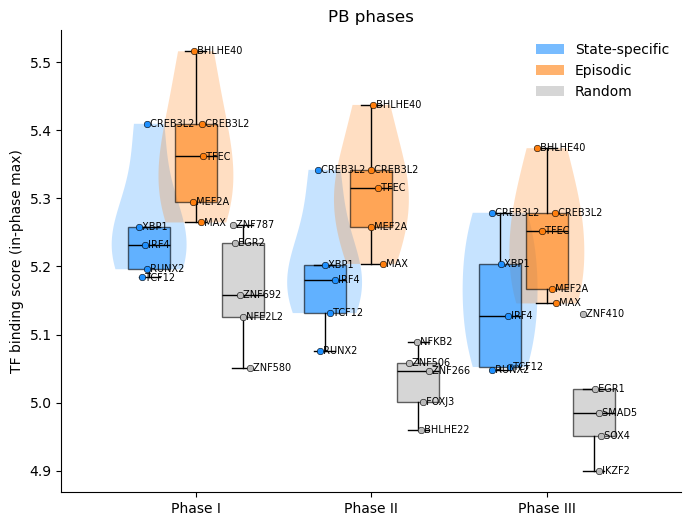

phase           1                       2                       3  \
category Episodic State-specific Episodic State-specific Episodic   
rank                                                                
1         BHLHE40        CREB3L2  BHLHE40        CREB3L2  BHLHE40   
2         CREB3L2           XBP1  CREB3L2           XBP1  CREB3L2   
3            TFEC           IRF4     TFEC           IRF4     TFEC   
4           MEF2A          RUNX2    MEF2A          TCF12    MEF2A   
5             MAX          TCF12      MAX          RUNX2      MAX   

phase                    
category State-specific  
rank                     
1               CREB3L2  
2                  XBP1  
3                  IRF4  
4                 TCF12  
5                 RUNX2

In [19]:
SEED = 0
fig, ax = bp_pb.plot_box(category_tfs_pb, top_k=5, annotate=True, violin=True,
                         random_control=True, random_state=SEED,
                         ylabel=BINDING_YLABEL,
                         category_cmaps={c: LINK_CMAPS[c] for c in category_tfs_pb},
                         control_cmap=LINK_CMAPS['random'])
ax.set_title('PB phases')
save_pdf(fig, "pb_tf_binding_in_phase")
plt.show()
display(bp_pb.top_tfs_table(category_tfs_pb, top_k=5)
        .pivot_table(index='rank', columns=['phase', 'category'], values='TF', aggfunc='first'))


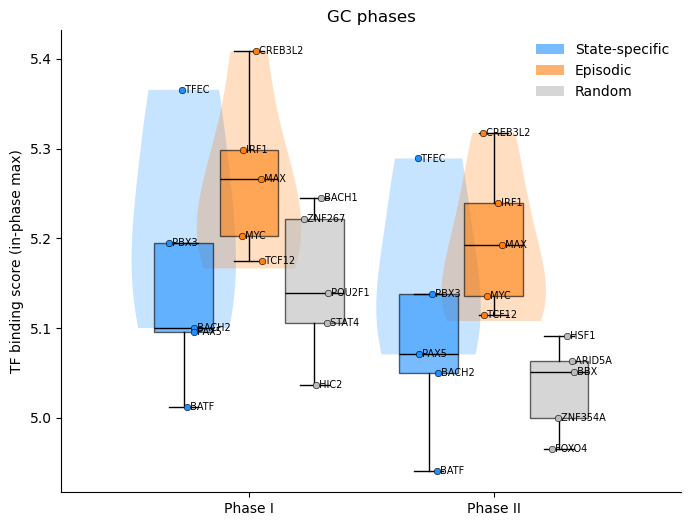

phase           1                       2               
category Episodic State-specific Episodic State-specific
rank                                                    
1         CREB3L2           TFEC  CREB3L2           TFEC
2            IRF1           PBX3     IRF1           PBX3
3             MAX          BACH2      MAX           PAX5
4             MYC           PAX5      MYC          BACH2
5           TCF12           BATF    TCF12           BATF

State-specific: TFs in both PB and GC top-5 = none
Episodic: TFs in both PB and GC top-5 = ['CREB3L2', 'MAX']


In [20]:
fig, ax = bp_gc.plot_box(category_tfs_gc, top_k=5, annotate=True, violin=True,
                         random_control=True, random_state=SEED,
                         ylabel=BINDING_YLABEL,
                         category_cmaps={c: LINK_CMAPS[c] for c in category_tfs_gc},
                         control_cmap=LINK_CMAPS['random'])
ax.set_title('GC phases')
save_pdf(fig, "gc_tf_binding_in_phase")
plt.show()
display(bp_gc.top_tfs_table(category_tfs_gc, top_k=5)
        .pivot_table(index='rank', columns=['phase', 'category'], values='TF', aggfunc='first'))

# Which episodic TFs are picked on both branches (possible only for TFs in X n Y).
_pb = bp_pb.top_tfs_table(category_tfs_pb, top_k=5)
_gc = bp_gc.top_tfs_table(category_tfs_gc, top_k=5)
for cat in ('State-specific', 'Episodic'):
    shared = set(_pb.loc[_pb.category == cat, 'TF']) & set(_gc.loc[_gc.category == cat, 'TF'])
    print(f'{cat}: TFs in both PB and GC top-5 = {sorted(shared) or "none"}')
